In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression

import re
import string
import nltk
from nltk.tokenize import word_tokenize, RegexpTokenizer
from nltk.stem import WordNetLemmatizer
from nltk.corpus import stopwords

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.metrics import roc_curve, auc


In [6]:
import pandas as pd
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

results = []

def add_results(model_name, y_true, y_pred, y_prob=None):
    row = {
        "Model": model_name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred),
        "Recall": recall_score(y_true, y_pred),
        "F1-score": f1_score(y_true, y_pred),
    }
    
    if y_prob is not None:
        row["AUC"] = roc_auc_score(y_true, y_prob)
    else:
        row["AUC"] = None
        
    results.append(row)


In [7]:
data=pd.read_csv('../../Reviews.csv')
data.head()

,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text
0,1,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1,1,5,1303862400,Good Quality Dog Food,I have bought several of the Vitality canned d...
1,2,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0,0,1,1346976000,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...
2,3,B000LQOCH0,ABXLMWJIXXAIN,"Natalia Corres ""Natalia Corres""",1,1,4,1219017600,"""Delight"" says it all",This is a confection that has been around a fe...
3,4,B000UA0QIQ,A395BORC6FGVXV,Karl,3,3,2,1307923200,Cough Medicine,If you are looking for the secret ingredient i...
4,5,B006K2ZZ7K,A1UQRSCLF8GW1T,"Michael D. Bigham ""M. Wassir""",0,0,5,1350777600,Great taffy,Great taffy at a great price. There was a wid...


In [10]:
# Dodaj .copy() na kraju filtriranja
data = data[data['Score'] != 3].copy()

# Sada možeš bezbedno da kreiraš kolonu
data['Sentiment'] = data['Score'].apply(lambda x: 'positive' if x > 3 else 'negative')


In [11]:
data.info()
data['Sentiment'].value_counts()

<class 'pandas.core.frame.DataFrame'>
Index: 525814 entries, 0 to 568453
Data columns (total 11 columns):
 #   Column                  Non-Null Count   Dtype 
---  ------                  --------------   ----- 
 0   Id                      525814 non-null  int64 
 1   ProductId               525814 non-null  object
 2   UserId                  525814 non-null  object
 3   ProfileName             525788 non-null  object
 4   HelpfulnessNumerator    525814 non-null  int64 
 5   HelpfulnessDenominator  525814 non-null  int64 
 6   Score                   525814 non-null  int64 
 7   Time                    525814 non-null  int64 
 8   Summary                 525789 non-null  object
 9   Text                    525814 non-null  object
 10  Sentiment               525814 non-null  object
dtypes: int64(5), object(6)
memory usage: 48.1+ MB


Sentiment
positive    443777
negative     82037
Name: count, dtype: int64

In [12]:
data["TextFull"] = data["Summary"].fillna("") + " " + data["Text"].fillna("")

In [13]:
data["Sentiment"] = data["Sentiment"].apply(lambda x: 1 if x == 'positive' else 0)

In [14]:
import ssl
import nltk
from nltk.tokenize import word_tokenize, RegexpTokenizer
from nltk.stem import WordNetLemmatizer
from nltk.corpus import stopwords
try:
    _create_unverified_https_context = ssl._create_unverified_context
except AttributeError:
    pass
else:
    ssl._create_default_https_context = _create_unverified_https_context

nltk.download('stopwords')
nltk.download('wordnet')


[nltk_data] Downloading package stopwords to /home/tamara/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /home/tamara/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [15]:
stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

In [16]:
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"[^a-z\s]", " ", text)
    words = text.split()
    words = [lemmatizer.lemmatize(w) for w in words if w not in stop_words]
    return " ".join(words)

In [17]:
data["cleaned_review"] = data["TextFull"].apply(clean_text)

In [18]:
final_df = data[["cleaned_review", "Sentiment"]]
final_df.head()

,cleaned_review,Sentiment
0,good quality dog food bought several vitality ...,1
1,advertised product arrived labeled jumbo salte...,0
2,delight say confection around century light pi...,1
3,cough medicine looking secret ingredient robit...,0
4,great taffy great taffy great price wide assor...,1


In [19]:
X_text = final_df["cleaned_review"]
y = final_df["Sentiment"]

X_train_text, X_test_text, y_train, y_test = train_test_split(
    X_text, y, test_size=0.2, random_state=42, stratify=y
)

tfidf = TfidfVectorizer(max_features=15000, ngram_range=(1,2), min_df=5)
X_train = tfidf.fit_transform(X_train_text)
X_test  = tfidf.transform(X_test_text)


In [20]:
import pandas as pd
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

model_outputs = {}  # ovde skupljamo rezultate svih modela


Naive Bayes accuracy: 91.43%

Classification Report:

              precision    recall  f1-score   support

           0       0.91      0.50      0.65     16407
           1       0.91      0.99      0.95     88756

    accuracy                           0.91    105163
   macro avg       0.91      0.75      0.80    105163
weighted avg       0.91      0.91      0.90    105163



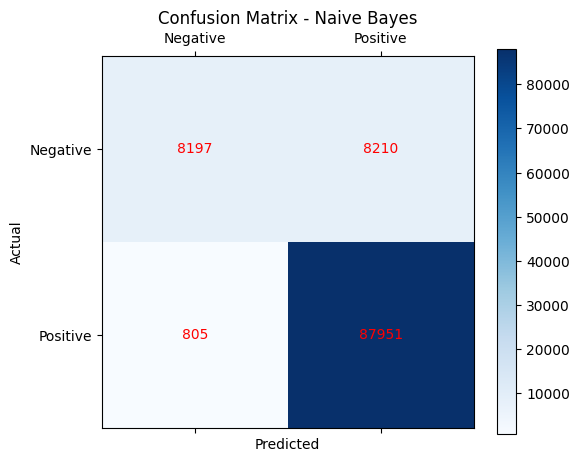

In [21]:
nb_model = MultinomialNB()
nb_model.fit(X_train, y_train)  
predictions = nb_model.predict(X_test)
accuracy = accuracy_score(y_test, predictions)
print("Naive Bayes accuracy:", "{:04.2f}".format(accuracy * 100) + "%\n")
print("Classification Report:\n")
print(classification_report(y_test, predictions))
cm = confusion_matrix(y_test, predictions)

fig, ax = plt.subplots(figsize=(6,5))
cax = ax.matshow(cm, cmap=plt.cm.Blues)  
plt.title('Confusion Matrix - Naive Bayes')
fig.colorbar(cax)

ax.set_xticks([0,1])
ax.set_yticks([0,1])
ax.set_xticklabels(['Negative', 'Positive'])
ax.set_yticklabels(['Negative', 'Positive'])
plt.xlabel('Predicted')
plt.ylabel('Actual')

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, str(cm[i,j]), va='center', ha='center', color='red')

plt.show()

In [22]:
nb_pred = predictions
nb_prob = nb_model.predict_proba(X_test)[:, 1]   # za AUC/ROC

model_outputs["Naive Bayes"] = {"y_pred": nb_pred, "y_score": nb_prob}


/home/tamara/.local/lib/python3.8/site-packages/sklearn/svm/_classes.py:32: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(


SVM (LinearSVC) accuracy: 95.61%

Classification Report:

              precision    recall  f1-score   support

           0       0.89      0.82      0.85     16407
           1       0.97      0.98      0.97     88756

    accuracy                           0.96    105163
   macro avg       0.93      0.90      0.91    105163
weighted avg       0.96      0.96      0.96    105163



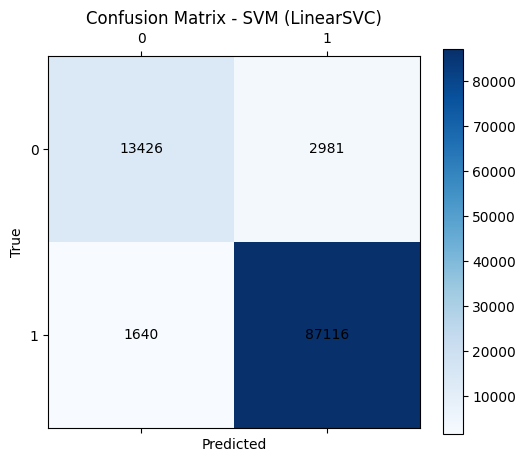

In [23]:
svm_model = LinearSVC(C=0.5, random_state=42)
svm_model.fit(X_train, y_train)

predictions = svm_model.predict(X_test)

accuracy = accuracy_score(y_test, predictions)
print("SVM (LinearSVC) accuracy:", "{:04.2f}".format(accuracy * 100) + "%\n")

print("Classification Report:\n")
print(classification_report(y_test, predictions))

cm = confusion_matrix(y_test, predictions)

fig, ax = plt.subplots(figsize=(6,5))
cax = ax.matshow(cm, cmap=plt.cm.Blues)
plt.title('Confusion Matrix - SVM (LinearSVC)')
fig.colorbar(cax)

ax.set_xlabel("Predicted")
ax.set_ylabel("True")

for (i, j), val in np.ndenumerate(cm):
    ax.text(j, i, str(val), ha='center', va='center')

plt.show()

In [24]:
svm_pred = predictions
svm_score = svm_model.decision_function(X_test)  # score za AUC/ROC (SVM nema predict_proba)

model_outputs["SVM (LinearSVC)"] = {"y_pred": svm_pred, "y_score": svm_score}


Logistic Regression accuracy: 95.22%

Classification Report:

              precision    recall  f1-score   support

           0       0.90      0.78      0.84     16407
           1       0.96      0.98      0.97     88756

    accuracy                           0.95    105163
   macro avg       0.93      0.88      0.90    105163
weighted avg       0.95      0.95      0.95    105163



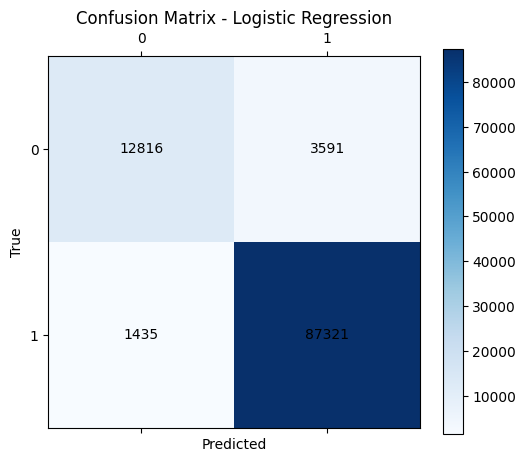

In [25]:
lr_model = LogisticRegression(
    max_iter=1000,
    n_jobs=-1,
    random_state=42
)

lr_model.fit(X_train, y_train)
predictions = lr_model.predict(X_test)

accuracy = accuracy_score(y_test, predictions)
print("Logistic Regression accuracy:", "{:04.2f}".format(accuracy * 100) + "%\n")

print("Classification Report:\n")
print(classification_report(y_test, predictions))

cm = confusion_matrix(y_test, predictions)

fig, ax = plt.subplots(figsize=(6,5))
cax = ax.matshow(cm, cmap=plt.cm.Blues)
plt.title('Confusion Matrix - Logistic Regression')
fig.colorbar(cax)

ax.set_xlabel("Predicted")
ax.set_ylabel("True")

for (i, j), val in np.ndenumerate(cm):
    ax.text(j, i, str(val), ha='center', va='center')

plt.show()

In [26]:
lr_pred = predictions
lr_prob = lr_model.predict_proba(X_test)[:, 1]

model_outputs["Logistic Regression"] = {"y_pred": lr_pred, "y_score": lr_prob}


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_curve, auc
import matplotlib.pyplot as plt
import numpy as np

# 1) Model
rf_model = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced_subsample"   # korisno ako su klase malo nebalansirane
)

# 2) Train
rf_model.fit(X_train, y_train)

# 3) Predikcije (klase)
predictions = rf_model.predict(X_test)

# 4) Accuracy + report
accuracy = accuracy_score(y_test, predictions)
print("Random Forest accuracy:", "{:04.2f}".format(accuracy * 100) + "%\n")

print("Classification Report:\n")
print(classification_report(y_test, predictions))

# 5) Confusion Matrix
cm = confusion_matrix(y_test, predictions)

fig, ax = plt.subplots(figsize=(6,5))
cax = ax.matshow(cm, cmap=plt.cm.Blues)
plt.title('Confusion Matrix - Random Forest')
fig.colorbar(cax)

ax.set_xlabel("Predicted")
ax.set_ylabel("True")

for (i, j), val in np.ndenumerate(cm):
    ax.text(j, i, str(val), ha='center', va='center')

plt.show()

# 6) ROC/AUC (Random Forest ima predict_proba)
y_prob = rf_model.predict_proba(X_test)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0,1], [0,1], lw=1, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Random Forest')
plt.legend(loc='lower right')
plt.show()


In [ ]:
rf_pred = predictions
rf_prob = rf_model.predict_proba(X_test)[:, 1]

model_outputs["Random Forest"] = {"y_pred": rf_pred, "y_score": rf_prob}


In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_curve, auc
import matplotlib.pyplot as plt
import numpy as np

# 1) Model
knn_model = KNeighborsClassifier(
    n_neighbors=7,       # probaj 5, 7, 9
    metric="cosine",     # dobro za tekst
    algorithm="brute",
    weights="distance"   # često malo bolje od uniform
)

# 2) Train
knn_model.fit(X_train, y_train)

# 3) Predikcije (klase)
predictions = knn_model.predict(X_test)

# 4) Accuracy + report
accuracy = accuracy_score(y_test, predictions)
print("kNN accuracy:", "{:04.2f}".format(accuracy * 100) + "%\n")

print("Classification Report:\n")
print(classification_report(y_test, predictions))

# 5) Confusion Matrix
cm = confusion_matrix(y_test, predictions)

fig, ax = plt.subplots(figsize=(6,5))
cax = ax.matshow(cm, cmap=plt.cm.Blues)
plt.title('Confusion Matrix - kNN')
fig.colorbar(cax)

ax.set_xlabel("Predicted")
ax.set_ylabel("True")

for (i, j), val in np.ndenumerate(cm):
    ax.text(j, i, str(val), ha='center', va='center')

plt.show()

# 6) ROC/AUC (kNN ima predict_proba)
y_prob = knn_model.predict_proba(X_test)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0,1], [0,1], lw=1, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - kNN')
plt.legend(loc='lower right')
plt.show()


In [ ]:
knn_pred = predictions
knn_prob = knn_model.predict_proba(X_test)[:, 1]

model_outputs["kNN"] = {"y_pred": knn_pred, "y_score": knn_prob}


In [ ]:
rows = []
for name, out in model_outputs.items():
    y_pred = out["y_pred"]
    y_score = out.get("y_score", None)

    row = {
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-score": f1_score(y_test, y_pred),
    }

    # AUC radi i za prob (0-1) i za score (SVM decision_function)
    if y_score is not None:
        row["AUC"] = roc_auc_score(y_test, y_score)
    else:
        row["AUC"] = np.nan

    rows.append(row)

results_df = pd.DataFrame(rows).sort_values("F1-score", ascending=False).reset_index(drop=True)

# lep prikaz (za notebook)
results_df.style.format({
    "Accuracy": "{:.4f}",
    "Precision": "{:.4f}",
    "Recall": "{:.4f}",
    "F1-score": "{:.4f}",
    "AUC": "{:.4f}",
})


In [ ]:
import pandas as pd

# pretpostavka: results_df je tvoja tabela
fmt = {
    "Accuracy": "{:.4f}",
    "Precision": "{:.4f}",
    "Recall": "{:.4f}",
    "F1-score": "{:.4f}",
    "AUC": "{:.4f}",
}

(results_df.style
 .format(fmt)
 .highlight_max(subset=["Accuracy","Precision","Recall","F1-score","AUC"], color="lightgreen")
 .set_caption("Model comparison on TF-IDF features (test set)")
)


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Ako results_df nije sortiran, možeš:
# results_df = results_df.sort_values("F1-score", ascending=False).reset_index(drop=True)

models = results_df["Model"].tolist()
acc = results_df["Accuracy"].values
f1  = results_df["F1-score"].values

x = np.arange(len(models))
width = 0.4

plt.figure(figsize=(10,5))
plt.bar(x - width/2, acc, width, label="Accuracy")
plt.bar(x + width/2, f1,  width, label="F1-score")

plt.xticks(x, models, rotation=25, ha="right")
plt.ylim(0, 1.0)
plt.ylabel("Score")
plt.title("Model Comparison: Accuracy vs F1-score")
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

plt.figure(figsize=(7,6))

for name, out in model_outputs.items():
    y_score = out.get("y_score", None)
    if y_score is None:
        continue
    
    fpr, tpr, _ = roc_curve(y_test, y_score)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=2, label=f"{name} (AUC={roc_auc:.3f})")

plt.plot([0, 1], [0, 1], linestyle="--", lw=1)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves (all models)")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()


In [ ]:
final_df["review_length"] = final_df["cleaned_review"].apply(len)

plt.figure(figsize=(6,4))
plt.hist(final_df["review_length"], bins=50)
plt.xlabel("Review length")
plt.ylabel("Frequency")
plt.title("Distribution of review lengths")
plt.show()
